In [1]:
# !pip install seaborn

In [2]:
# import os
# os.makedirs('/content/drive/MyDrive/FinalProject/figures', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Loaded from Drive JSON files

STATISTICAL SUMMARY — Human vs AI-trained

Llama-3.2-1B:
  TTR    0.3652 → 0.2766   drop 24.3%   Cohen's d = 11.9
  Vocab  1664 → 1279      drop 23.1%
  Bigram 0.7909 → 0.5896   drop 25.5%

Mistral-7B-v0.3:
  TTR    0.3298 → 0.2783   drop 15.6%   Cohen's d = 6.3
  Vocab  1523 → 1211      drop 20.5%
  Bigram 0.7721 → 0.5998   drop 22.3%


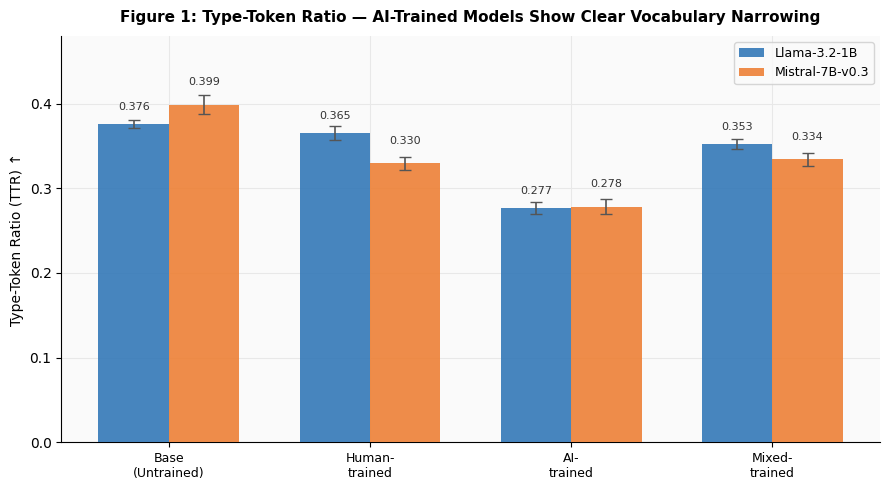

✓ figure1_ttr.png


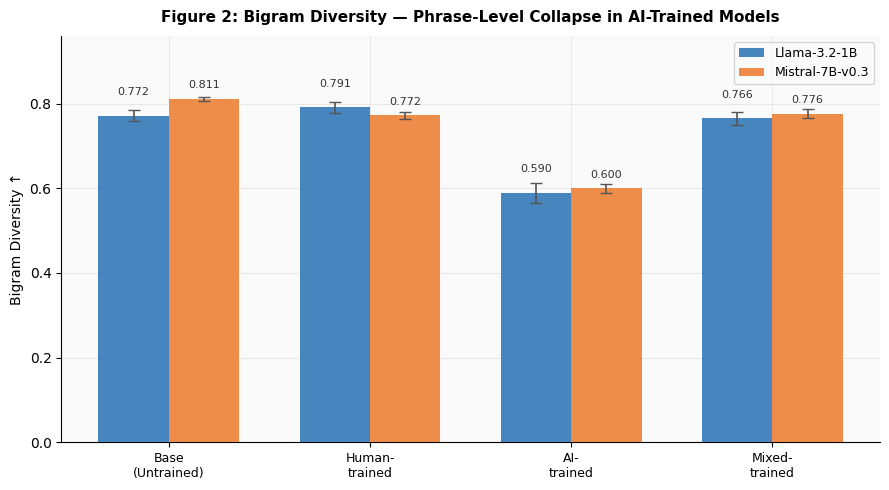

✓ figure2_bigram.png


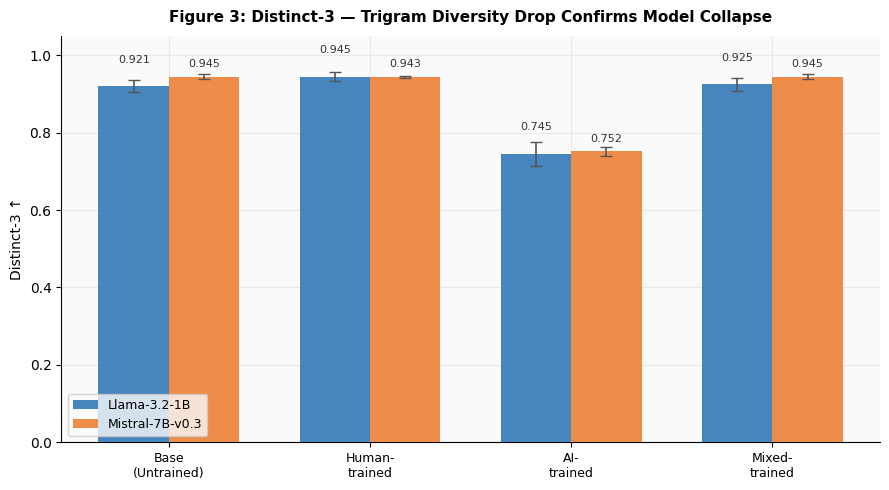

✓ figure3_distinct3.png


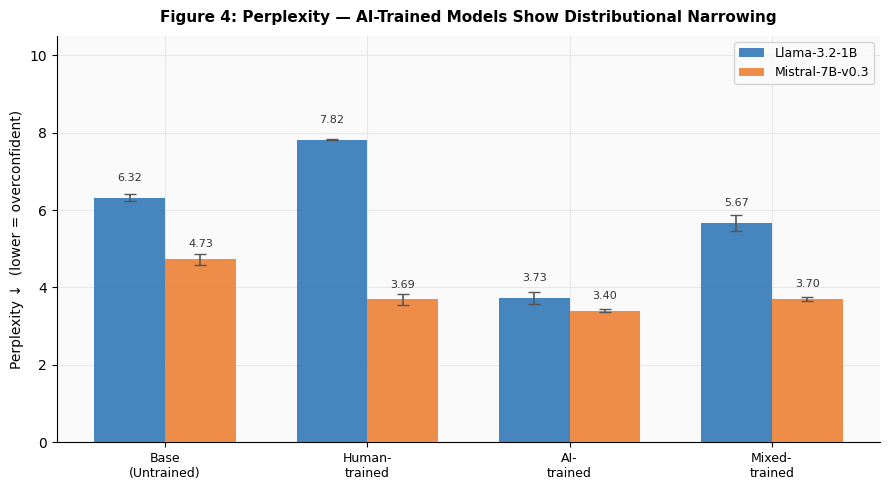

✓ figure4_perplexity.png


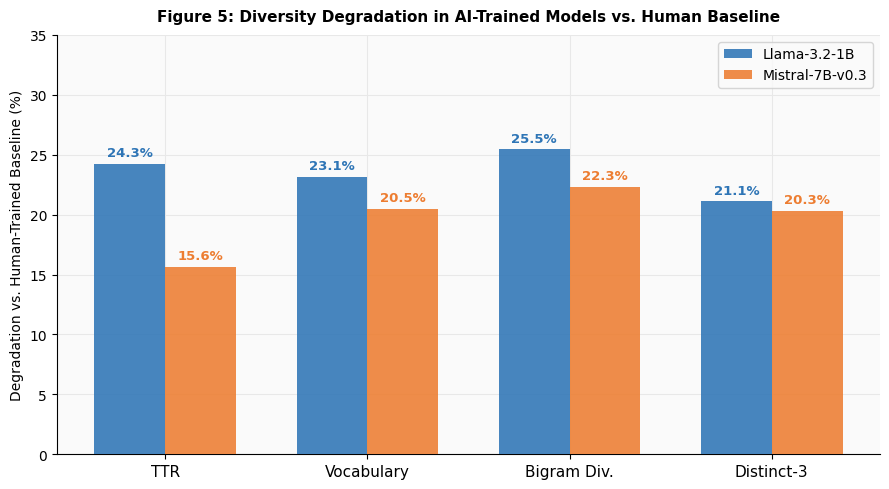

✓ figure5_degradation.png

✓ All 5 figures saved to /content/drive/MyDrive/FinalProject/figures/


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import json, os

from google.colab import drive
drive.mount('/content/drive')

project_root = '/content/drive/MyDrive/FinalProject'

# ── Load data ─────────────────────────────────────────────────────────────────
try:
    with open(f'{project_root}/evaluation_results_final.json') as f:
        lr = json.load(f)
    with open(f'{project_root}/evaluation_results_final_mistral.json') as f:
        mr = json.load(f)

    _models = ['Base (Untrained)', 'Human-trained', 'AI-trained', 'Mixed-trained']
    def _get(res, model, *keys):
        node = res[model]
        for k in keys: node = node[k]
        return (node['mean'], node['std'])

    def _extract(res):
        return {k: [_get(res, m, *path) for m in _models] for k, path in {
            'ttr':   ('lexical_diversity', 'type_token_ratio'),
            'vocab': ('lexical_diversity', 'vocabulary_size'),
            'bigram':('lexical_diversity', 'bigram_diversity'),
            'dist3': ('lexical_diversity', 'distinct_3'),
            'ppl':   ('perplexity',),
        }.items()}

    llama   = _extract(lr)
    mistral = _extract(mr)
    print("✓ Loaded from Drive JSON files")

except Exception as e:
    print(f"JSON not found ({e}), using hardcoded values")
    llama = {
        'ttr':   [(0.3759,0.0043),(0.3652,0.0079),(0.2766,0.0070),(0.3526,0.0062)],
        'vocab': [(1636,45),      (1664,24),       (1279,40),      (1628,21)      ],
        'bigram':[(0.7717,0.0128),(0.7909,0.0127),(0.5896,0.0239),(0.7657,0.0154)],
        'dist3': [(0.9207,0.0148),(0.9448,0.0114),(0.7454,0.0306),(0.9250,0.0174)],
        'ppl':   [(6.32,0.09),    (7.82,0.02),     (3.73,0.16),    (5.67,0.21)   ],
    }
    mistral = {
        'ttr':   [(0.3987,0.0114),(0.3298,0.0077),(0.2783,0.0086),(0.3343,0.0074)],
        'vocab': [(1633,21),      (1523,20),       (1211,24),      (1521,39)      ],
        'bigram':[(0.8109,0.0053),(0.7721,0.0078),(0.5998,0.0115),(0.7762,0.0106)],
        'dist3': [(0.9450,0.0057),(0.9433,0.0032),(0.7517,0.0112),(0.9448,0.0073)],
        'ppl':   [(4.73,0.14),    (3.69,0.14),     (3.40,0.04),    (3.70,0.06)   ],
    }

os.makedirs(f'{project_root}/figures', exist_ok=True)

# ── Statistical summary ───────────────────────────────────────────────────────
def cohens_d(m1, s1, m2, s2):
    pooled = np.sqrt((s1**2 + s2**2) / 2)
    return (m1 - m2) / pooled if pooled > 0 else 0

print("\n" + "="*55)
print("STATISTICAL SUMMARY — Human vs AI-trained")
print("="*55)
for label, data in [('Llama-3.2-1B', llama), ('Mistral-7B-v0.3', mistral)]:
    hm, hs = data['ttr'][1];    am, as_ = data['ttr'][2]
    vm      = data['vocab'][1][0]; avm    = data['vocab'][2][0]
    bm      = data['bigram'][1][0]; abm   = data['bigram'][2][0]
    d = cohens_d(hm, hs, am, as_)
    print(f"\n{label}:")
    print(f"  TTR    {hm:.4f} → {am:.4f}   drop {(hm-am)/hm*100:.1f}%   Cohen's d = {d:.1f}")
    print(f"  Vocab  {vm:.0f} → {avm:.0f}      drop {(vm-avm)/vm*100:.1f}%")
    print(f"  Bigram {bm:.4f} → {abm:.4f}   drop {(bm-abm)/bm*100:.1f}%")

# ── Style ─────────────────────────────────────────────────────────────────────
LLAMA_COLOR   = '#2E75B6'
MISTRAL_COLOR = '#ED7D31'
model_labels  = ['Base\n(Untrained)', 'Human-\ntrained', 'AI-\ntrained', 'Mixed-\ntrained']
x     = np.arange(len(model_labels))
width = 0.35

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E8E8E8', 'grid.linewidth': 0.8,
    'axes.facecolor': '#FAFAFA', 'figure.facecolor': 'white',
})

def bar_pair(ax, key, ylabel, title, fmt='.3f', ylim=None):
    lm = [v[0] for v in llama[key]];   ls = [v[1] for v in llama[key]]
    mm = [v[0] for v in mistral[key]]; ms = [v[1] for v in mistral[key]]
    b1 = ax.bar(x - width/2, lm, width, yerr=ls, capsize=4, label='Llama-3.2-1B',
                color=LLAMA_COLOR, alpha=0.88, zorder=3,
                error_kw=dict(elinewidth=1.2, ecolor='#555'))
    b2 = ax.bar(x + width/2, mm, width, yerr=ms, capsize=4, label='Mistral-7B-v0.3',
                color=MISTRAL_COLOR, alpha=0.88, zorder=3,
                error_kw=dict(elinewidth=1.2, ecolor='#555'))
    for bar, val in zip(b1, lm):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(ls)*1.8,
                format(val, fmt), ha='center', va='bottom', fontsize=8, color='#333')
    for bar, val in zip(b2, mm):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(ms)*1.8,
                format(val, fmt), ha='center', va='bottom', fontsize=8, color='#333')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xticks(x); ax.set_xticklabels(model_labels, fontsize=9)
    ax.legend(fontsize=9); ax.set_axisbelow(True)
    if ylim: ax.set_ylim(*ylim)

# ── Figure 1: TTR ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bar_pair(ax, 'ttr', 'Type-Token Ratio (TTR) ↑',
         'Figure 1: Type-Token Ratio — AI-Trained Models Show Clear Vocabulary Narrowing',
         ylim=(0, 0.48))
plt.tight_layout()
plt.savefig(f'{project_root}/figures/figure1_ttr.png', dpi=180, bbox_inches='tight')
plt.show(); print("✓ figure1_ttr.png")

# ── Figure 2: Bigram Diversity ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bar_pair(ax, 'bigram', 'Bigram Diversity ↑',
         'Figure 2: Bigram Diversity — Phrase-Level Collapse in AI-Trained Models',
         ylim=(0, 0.96))
plt.tight_layout()
plt.savefig(f'{project_root}/figures/figure2_bigram.png', dpi=180, bbox_inches='tight')
plt.show(); print("✓ figure2_bigram.png")

# ── Figure 3: Distinct-3 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bar_pair(ax, 'dist3', 'Distinct-3 ↑',
         'Figure 3: Distinct-3 — Trigram Diversity Drop Confirms Model Collapse',
         ylim=(0, 1.05))
plt.tight_layout()
plt.savefig(f'{project_root}/figures/figure3_distinct3.png', dpi=180, bbox_inches='tight')
plt.show(); print("✓ figure3_distinct3.png")

# ── Figure 4: Perplexity ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
bar_pair(ax, 'ppl', 'Perplexity ↓  (lower = overconfident)',
         'Figure 4: Perplexity — AI-Trained Models Show Distributional Narrowing',
         fmt='.2f', ylim=(0, 10.5))
plt.tight_layout()
plt.savefig(f'{project_root}/figures/figure4_perplexity.png', dpi=180, bbox_inches='tight')
plt.show(); print("✓ figure4_perplexity.png")

# ── Figure 5: Degradation % ───────────────────────────────────────────────────
deg_keys   = ['ttr', 'vocab', 'bigram', 'dist3']
deg_labels = ['TTR', 'Vocabulary', 'Bigram Div.', 'Distinct-3']
llama_deg   = [(llama[k][1][0]   - llama[k][2][0])   / llama[k][1][0]   * 100 for k in deg_keys]
mistral_deg = [(mistral[k][1][0] - mistral[k][2][0]) / mistral[k][1][0] * 100 for k in deg_keys]
x2 = np.arange(len(deg_labels))

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x2 - width/2, llama_deg,   width, label='Llama-3.2-1B',   color=LLAMA_COLOR,   alpha=0.88, zorder=3)
b2 = ax.bar(x2 + width/2, mistral_deg, width, label='Mistral-7B-v0.3', color=MISTRAL_COLOR, alpha=0.88, zorder=3)
for bar, val in zip(b1, llama_deg):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold', color=LLAMA_COLOR)
for bar, val in zip(b2, mistral_deg):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold', color=MISTRAL_COLOR)
ax.set_ylabel('Degradation vs. Human-Trained Baseline (%)', fontsize=10)
ax.set_title('Figure 5: Diversity Degradation in AI-Trained Models vs. Human Baseline',
             fontsize=11, fontweight='bold', pad=10)
ax.set_xticks(x2); ax.set_xticklabels(deg_labels, fontsize=11)
ax.set_ylim(0, 35); ax.legend(fontsize=10); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(f'{project_root}/figures/figure5_degradation.png', dpi=180, bbox_inches='tight')
plt.show(); print("✓ figure5_degradation.png")

print(f"\n✓ All 5 figures saved to {project_root}/figures/")
